# Olas de calor en el sedimento de los lagos

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**El fondo profundo de un lago podría pasar casi cuatro meses al año en condiciones de ola de calor.** Eso es lo que proyecta un ensemble de modelos climáticos publicado en *Nature Geoscience* — y no es la superficie la que más cambia, sino lo que está debajo.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-01-olas-calor-sedimentos-lagos/notebook.ipynb)

**Paper:** Lake sediment heatwaves under global warming — *Nature Geoscience*, 1 de junio de 2026
**DOI:** [10.1038/s41561-026-01986-3](https://doi.org/10.1038/s41561-026-01986-3)
**Datos:** [Zenodo 18507326](https://doi.org/10.5281/zenodo.18507326)

## Qué midieron — y dónde está la novedad

Los autores corrieron simulaciones diarias de temperatura en 41.499 lagos del planeta, durante dos ventanas de 30 años: el clima reciente (1981-2010) y el clima futuro (2071-2100), bajo tres escenarios de emisiones (SSP1-2.6, SSP3-7.0 y SSP5-8.5). El modelo lacustre fue forzado con la salida bias-corrected de cinco modelos climáticos globales (GCMs) del proyecto ISIMIP3b — aquí reproducimos tres de los cinco.

Definieron tres tipos de ola de calor por lago:

- **SHW** — *surface heatwave*: ola de calor en la capa de agua superficial.
- **PHW** — *pelagic sediment heatwave*: ola de calor en el sedimento del fondo, en zona profunda (pelágica).
- **LHW** — *littoral sediment heatwave*: ola de calor en el sedimento somero, cerca de la orilla.

La pregunta del paper: ¿cómo cambian estas tres en duración, frecuencia y desfase temporal cuando sube la temperatura del aire?

In [1]:
# ═══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ═══════════════════════════════════════════════════════════════
SSP_FOCO = 'ssp585'                         # escenario para gráficas comparativas (ssp126/ssp370/ssp585)
TIPO_FOCO = 'PHW'                           # tipo de heatwave a destacar (SHW/PHW/LHW)
FUENTE = 'Fuente: Pilla et al. (2026), Nature Geoscience | Datos: Zenodo 18507326'
COLOR_SUPERFICIE = '#D97706'                # SHW — amber, superficie
COLOR_PELAGICO = '#2563EB'                  # PHW — azul CaM, sedimento profundo
COLOR_LITORAL = '#059669'                   # LHW — emerald, sedimento somero
COLOR_REFERENCIA = '#DC2626'                # marcador del histórico

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de los 3 CSVs derivados del ensemble (3 GCMs × 3 SSPs)
df_metricas = pd.read_csv('datos/ensemble_metricas.csv')
df_cambios = pd.read_csv('datos/cambios_hist_vs_fut.csv')
df_bandas = pd.read_csv('datos/ensemble_bandas.csv')

print(f'Métricas ensemble: {len(df_metricas)} filas')
print(f'Cambios hist→fut: {len(df_cambios)} filas')
print(f'Bandas latitudinales: {len(df_bandas)} filas')
print(f'\nTipos disponibles: {sorted(df_metricas.tipo.unique())}')
print(f'SSPs: {sorted(df_metricas.ssp.unique())}')
print(f'Métricas: {sorted(df_metricas.metrica.unique())}')

Métricas ensemble: 114 filas
Cambios hist→fut: 57 filas
Bandas latitudinales: 360 filas

Tipos disponibles: ['LHW', 'PHW', 'SHW']
SSPs: ['ssp126', 'ssp370', 'ssp585']
Métricas: ['count', 'cum', 'dur', 'int', 'lag_dias', 'pct_no_shw', 'tot']


## Aquí está.

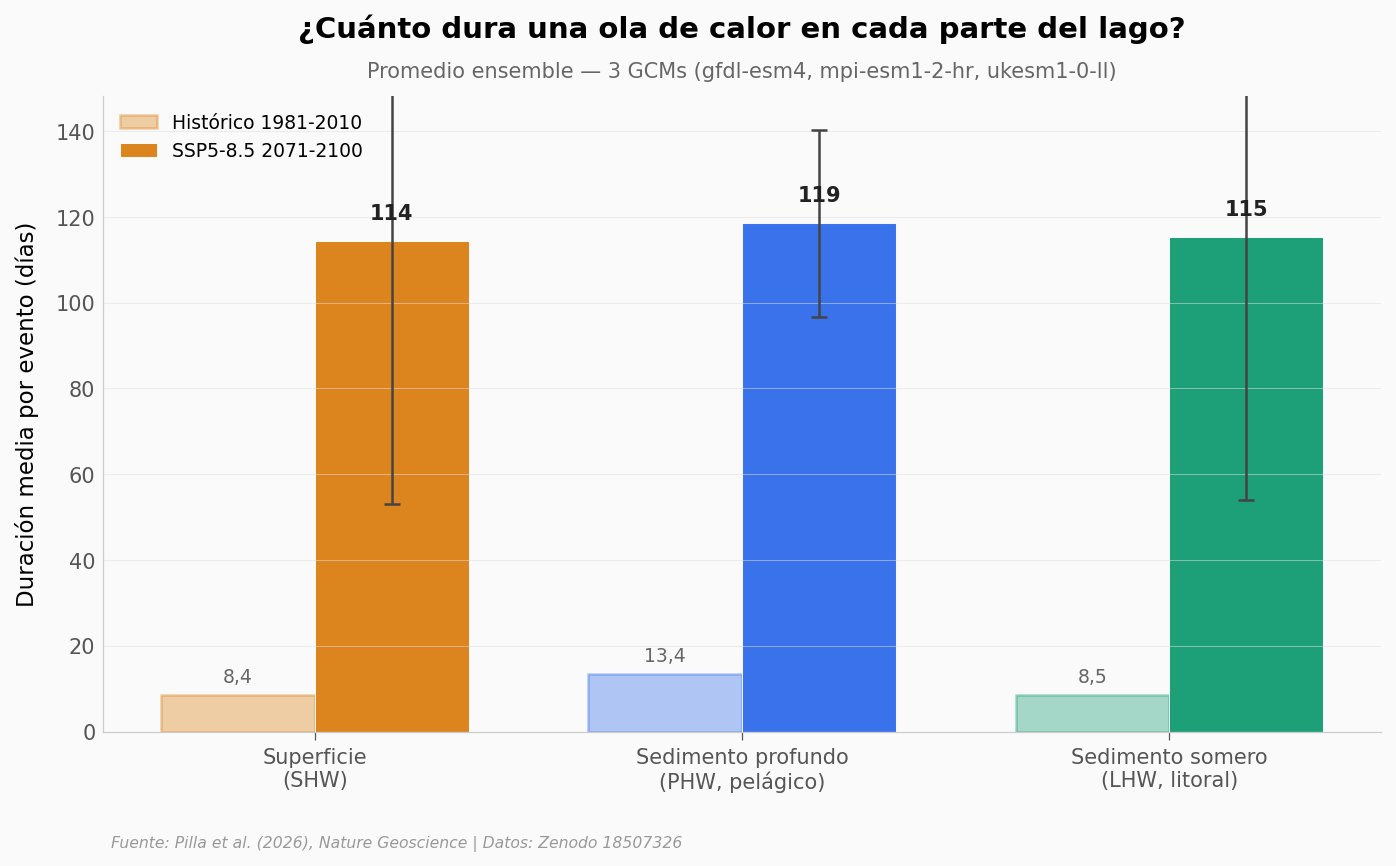

In [2]:
# Duración media por evento (días) — los 3 tipos, histórico vs SSP5-8.5 futuro
dur = df_metricas[df_metricas.metrica == 'dur'].copy()

def pick(ssp, tipo, periodo):
    row = dur[(dur.ssp == ssp) & (dur.tipo == tipo) & (dur.periodo == periodo)]
    return row.ensemble_mean.values[0], row.ensemble_std.values[0]

# Histórico — tomamos el promedio de los 3 SSPs (deberían ser idénticos en hist; chequeo abajo)
hist_shw = dur[(dur.tipo == 'SHW') & (dur.periodo == 'hist')].ensemble_mean.mean()
hist_phw = dur[(dur.tipo == 'PHW') & (dur.periodo == 'hist')].ensemble_mean.mean()
hist_lhw = dur[(dur.tipo == 'LHW') & (dur.periodo == 'hist')].ensemble_mean.mean()

fut585_shw, std_shw = pick('ssp585', 'SHW', 'fut')
fut585_phw, std_phw = pick('ssp585', 'PHW', 'fut')
fut585_lhw, std_lhw = pick('ssp585', 'LHW', 'fut')

fig, ax = plt.subplots(figsize=(11, 5.5))
labels = ['Superficie\n(SHW)', 'Sedimento profundo\n(PHW, pelágico)', 'Sedimento somero\n(LHW, litoral)']
x = np.arange(3)
w = 0.36
hist_vals = [hist_shw, hist_phw, hist_lhw]
fut_vals = [fut585_shw, fut585_phw, fut585_lhw]
fut_errs = [std_shw, std_phw, std_lhw]
colors_tipo = [COLOR_SUPERFICIE, COLOR_PELAGICO, COLOR_LITORAL]

bars_h = ax.bar(x - w/2, hist_vals, w, color=colors_tipo, alpha=0.35,
                edgecolor=colors_tipo, linewidth=1.2, label='Histórico 1981-2010')
bars_f = ax.bar(x + w/2, fut_vals, w, color=colors_tipo, alpha=0.9,
                edgecolor='white', linewidth=0.5, yerr=fut_errs,
                error_kw=dict(ecolor='#444444', capsize=4, capthick=1.2, lw=1.2),
                label='SSP5-8.5 2071-2100')

# Etiquetas de valor encima de cada barra
for xi, val in zip(x - w/2, hist_vals):
    ax.text(xi, val + 3, f'{val:.1f}'.replace('.', ','), ha='center', fontsize=9, color='#666666')
for xi, val in zip(x + w/2, fut_vals):
    ax.text(xi, val + 5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold', color='#222222')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Duración media por evento (días)', fontsize=11)
ax.set_title('¿Cuánto dura una ola de calor en cada parte del lago?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Promedio ensemble — 3 GCMs (gfdl-esm4, mpi-esm1-2-hr, ukesm1-0-ll)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.set_ylim(0, max(fut_vals) * 1.25)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

import os; os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/persistencia_hist_vs_fut.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención no es que las duraciones suban — eso es esperado — sino el patrón entre los tres tipos. En el clima histórico, el sedimento profundo (PHW) ya dura un 60% más por evento que la superficie: 13,4 días contra 8,4. Eso es nuevo conceptualmente: el fondo del lago amortigua y alarga las anomalías térmicas que llegan desde arriba.

El sedimento somero (LHW), en cambio, se comporta casi igual que la superficie (8,5 vs 8,4 días). Pegado a la orilla, sin mucha columna de agua encima, está acoplado térmicamente con el aire. La distinción **pelágico vs litoral** es la que el paper subraya — y la que conviene mantener si alguien quiere parafrasear el hallazgo: *los sedimentos profundos* aguantan más, no *los sedimentos* a secas.

Bajo SSP5-8.5, el modelo proyecta que la superficie alcanza al fondo: los tres tipos convergen alrededor de 114-119 días por evento — un horno casi permanente.

## ¿Y bajo escenarios más moderados?

La diferencia entre SSPs no es proporcional. Veamos cómo escala la duración del PHW (sedimento pelágico) en cada uno de los tres escenarios climáticos.

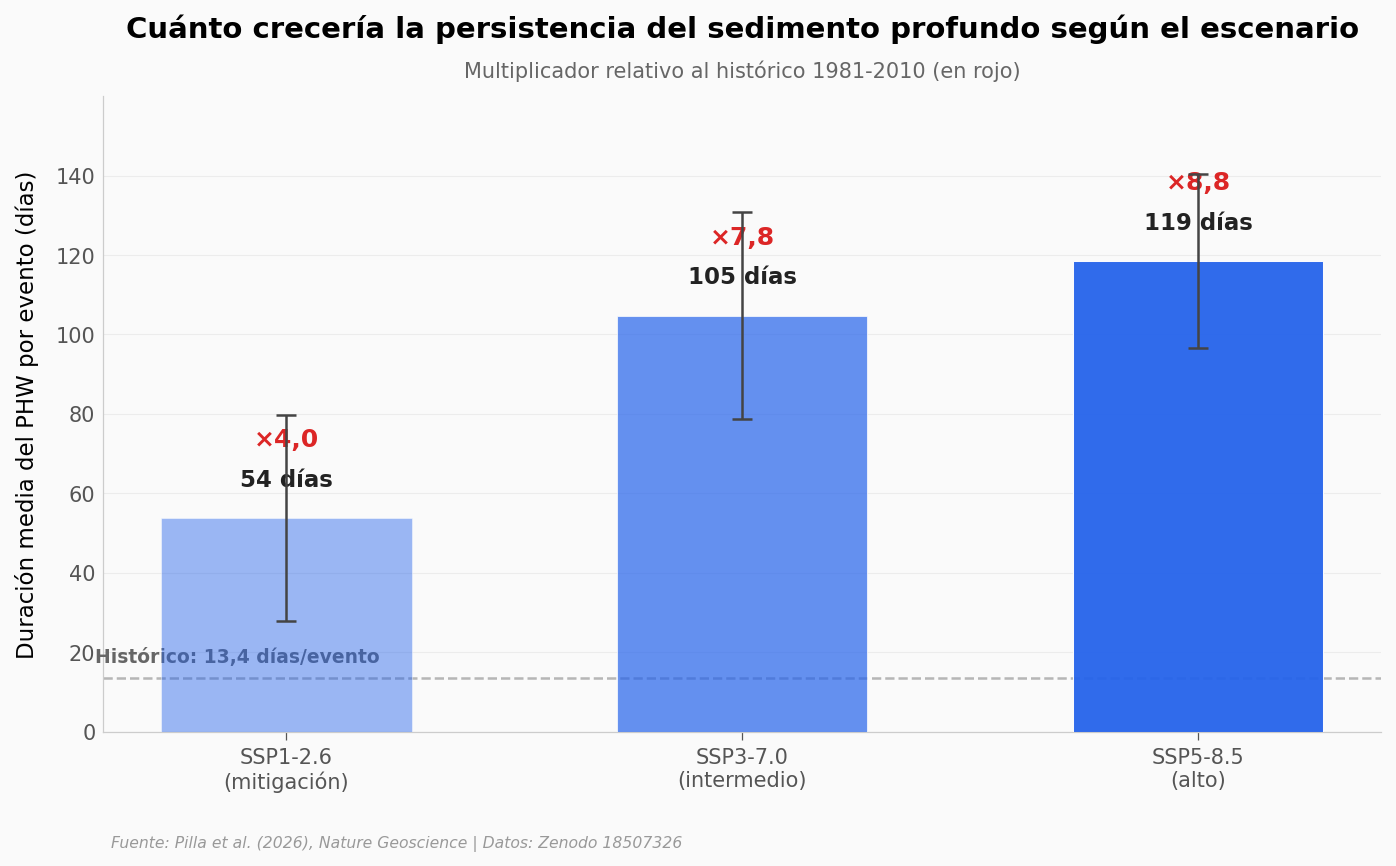


Multiplicadores PHW dur (hist=13.43 días):
  ssp126: ×4.01  →  53.8 días/evento
  ssp370: ×7.80  →  104.7 días/evento
  ssp585: ×8.82  →  118.5 días/evento


In [3]:
# Duración PHW por SSP, hist vs fut
phw_dur = df_metricas[(df_metricas.tipo == 'PHW') & (df_metricas.metrica == 'dur')].copy()
ssps = ['ssp126', 'ssp370', 'ssp585']
hist_phw_val = phw_dur[phw_dur.periodo == 'hist'].ensemble_mean.mean()

fut_means = [phw_dur[(phw_dur.ssp == s) & (phw_dur.periodo == 'fut')].ensemble_mean.values[0] for s in ssps]
fut_stds = [phw_dur[(phw_dur.ssp == s) & (phw_dur.periodo == 'fut')].ensemble_std.values[0] for s in ssps]
multiplicadores = [v / hist_phw_val for v in fut_means]

fig, ax = plt.subplots(figsize=(11, 5.5))
ssp_labels = ['SSP1-2.6\n(mitigación)', 'SSP3-7.0\n(intermedio)', 'SSP5-8.5\n(alto)']
x = np.arange(3)

# Línea de referencia: histórico
ax.axhline(y=hist_phw_val, color='#999999', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)
ax.text(-0.42, hist_phw_val + 4, f'Histórico: {hist_phw_val:.1f} días/evento'.replace('.', ','),
        fontsize=9, color='#666666', ha='left', fontweight='bold')

bars = ax.bar(x, fut_means, 0.55, color=COLOR_PELAGICO, edgecolor='white', linewidth=0.5,
              yerr=fut_stds, error_kw=dict(ecolor='#444444', capsize=5, capthick=1.2, lw=1.2),
              zorder=5)
for bar, a in zip(bars, [0.45, 0.7, 0.95]):
    bar.set_alpha(a)

# Etiquetas: valor + multiplicador
for xi, val, mult in zip(x, fut_means, multiplicadores):
    ax.text(xi, val + 8, f'{val:.0f} días', ha='center', fontsize=11, fontweight='bold', color='#222222')
    ax.text(xi, val + 18, f'×{mult:.1f}'.replace('.', ','), ha='center', fontsize=12,
            fontweight='bold', color=COLOR_REFERENCIA)

ax.set_xticks(x)
ax.set_xticklabels(ssp_labels, fontsize=10)
ax.set_ylabel('Duración media del PHW por evento (días)', fontsize=11)
ax.set_title('Cuánto crecería la persistencia del sedimento profundo según el escenario',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Multiplicador relativo al histórico 1981-2010 (en rojo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, max(fut_means) * 1.35)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/multiplicador_ssp.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nMultiplicadores PHW dur (hist={hist_phw_val:.2f} días):')
for s, m, v in zip(ssps, multiplicadores, fut_means):
    print(f'  {s}: ×{m:.2f}  →  {v:.1f} días/evento')

## Hay otro síntoma menos visible

En el clima histórico, cuando empieza una ola de calor en la superficie, pasan aproximadamente 22 días antes de que el sedimento profundo "se entere". Es el retardo térmico clásico — la columna de agua actúa como amortiguador. Esa demora es justamente lo que protege a la fauna bentónica de los picos térmicos transitorios.

Veamos qué ocurre con ese lag bajo cada escenario.

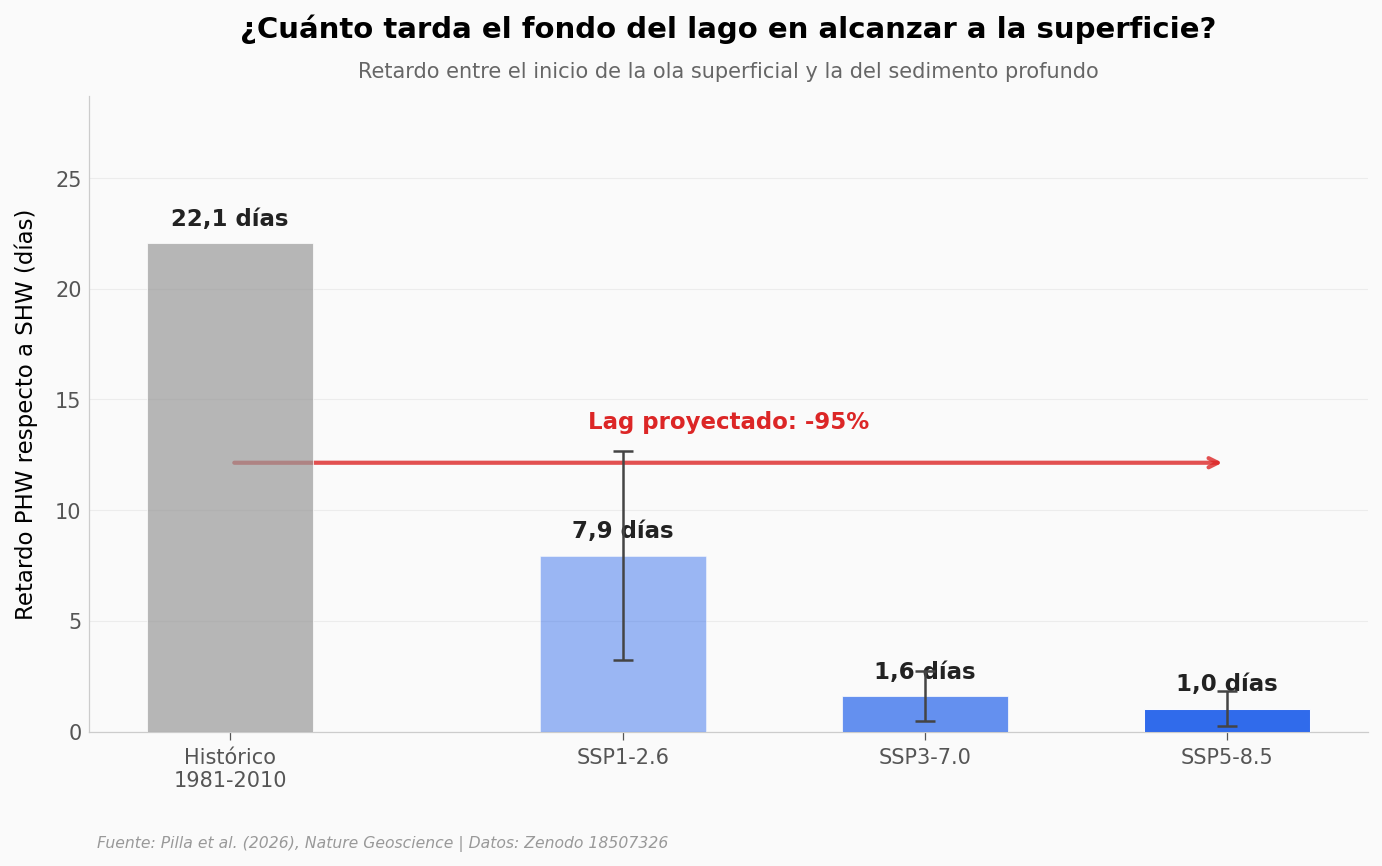


Lag PHW–SHW: hist=22,1 días → SSP585=1,0 días
Reducción relativa: -95%


In [4]:
# Lag (días) del PHW respecto al inicio del SHW correspondiente
lag = df_metricas[(df_metricas.tipo == 'PHW') & (df_metricas.metrica == 'lag_dias')].copy()
hist_lag = lag[lag.periodo == 'hist'].ensemble_mean.mean()
fut_lag_means = [lag[(lag.ssp == s) & (lag.periodo == 'fut')].ensemble_mean.values[0] for s in ssps]
fut_lag_stds = [lag[(lag.ssp == s) & (lag.periodo == 'fut')].ensemble_std.values[0] for s in ssps]

fig, ax = plt.subplots(figsize=(11, 5.5))

# Posiciones: hist + 3 SSPs
positions = [0, 1.3, 2.3, 3.3]
all_means = [hist_lag] + fut_lag_means
all_stds = [0] + fut_lag_stds
all_labels = ['Histórico\n1981-2010', 'SSP1-2.6', 'SSP3-7.0', 'SSP5-8.5']
all_colors = ['#999999', COLOR_PELAGICO, COLOR_PELAGICO, COLOR_PELAGICO]
all_alphas = [0.7, 0.45, 0.7, 0.95]

for pos, mean, std, col, a in zip(positions, all_means, all_stds, all_colors, all_alphas):
    ax.bar(pos, mean, 0.55, color=col, alpha=a, edgecolor='white', linewidth=0.5,
           yerr=std if std > 0 else None,
           error_kw=dict(ecolor='#444444', capsize=5, capthick=1.2, lw=1.2), zorder=5)
    label = f'{mean:.1f}'.replace('.', ',') + ' días'
    ax.text(pos, mean + 0.8, label, ha='center', fontsize=11, fontweight='bold', color='#222222')

# Flecha indicando el colapso
ax.annotate('', xy=(3.3, hist_lag * 0.55), xytext=(0, hist_lag * 0.55),
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=2, alpha=0.8))
ax.text(1.65, hist_lag * 0.62, 'Lag proyectado: -95%',
        ha='center', fontsize=11, fontweight='bold', color=COLOR_REFERENCIA)

ax.set_xticks(positions)
ax.set_xticklabels(all_labels, fontsize=10)
ax.set_ylabel('Retardo PHW respecto a SHW (días)', fontsize=11)
ax.set_title('¿Cuánto tarda el fondo del lago en alcanzar a la superficie?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Retardo entre el inicio de la ola superficial y la del sedimento profundo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, max(all_means) * 1.30)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/lag_colapso.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nLag PHW–SHW: hist={hist_lag:.1f} días → SSP585={fut_lag_means[2]:.1f} días'.replace('.', ','))
print(f'Reducción relativa: {(fut_lag_means[2] - hist_lag) / hist_lag * 100:.0f}%')

## ¿Es el mismo cambio en todo el planeta?

No. La duración de un PHW en el futuro depende fuertemente de la latitud — los lagos tropicales y los polares no juegan en la misma liga.

Tomemos la distribución de la duración media del PHW por banda latitudinal (Tropical / Temperada / Subpolar / Polar), comparando histórico con los tres SSPs futuros.

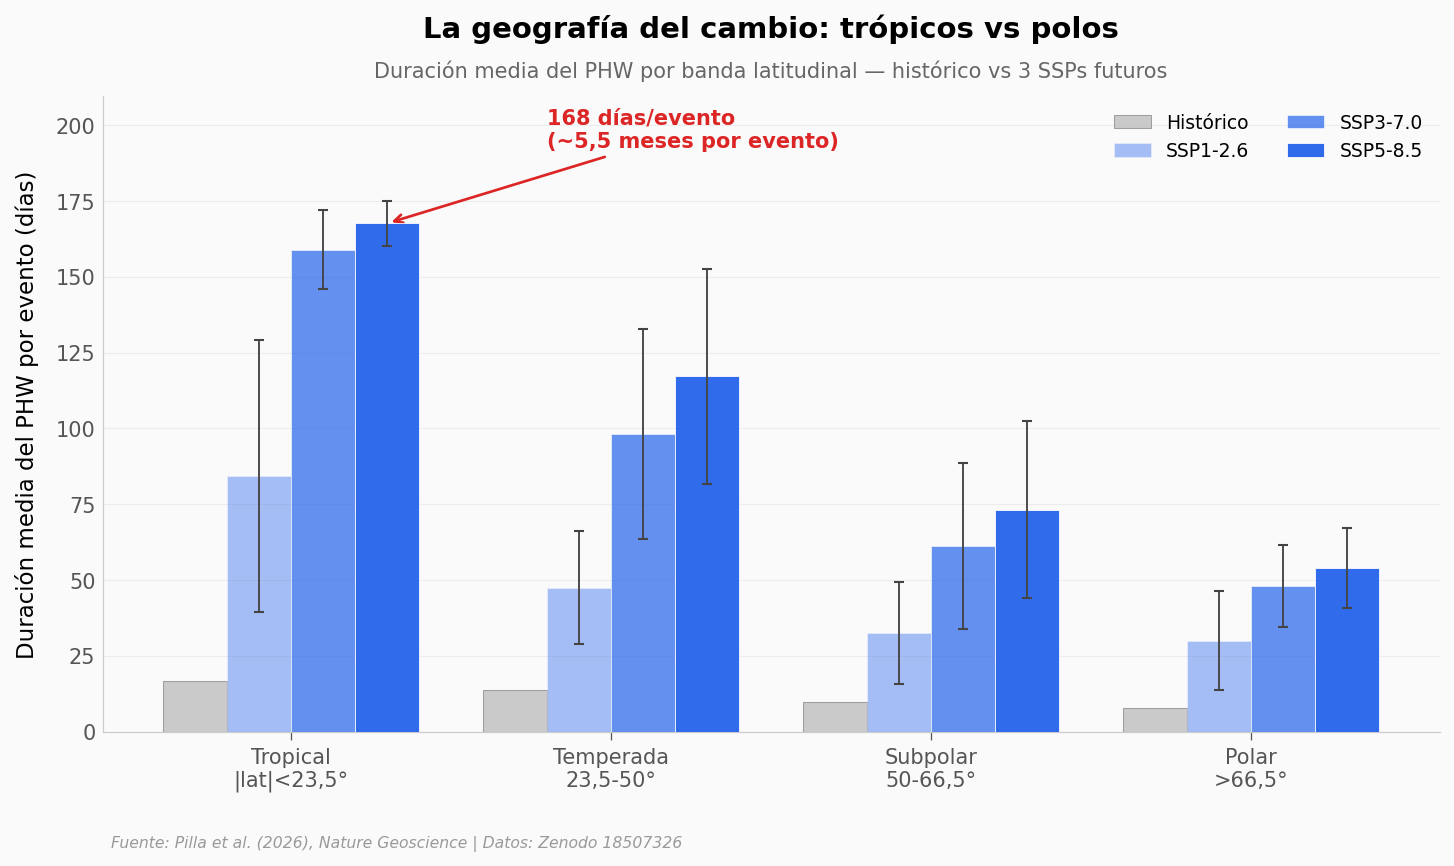


Duración media de un evento PHW (días) por banda — SSP5-8.5 futuro:
  Tropical: 167,6 días por evento
  Temperada: 117,1 días por evento
  Subpolar: 73,2 días por evento
  Polar: 54,0 días por evento


In [5]:
# PHW duración media por banda latitudinal y escenario
phw_bandas = df_bandas[(df_bandas.tipo == 'PHW') & (df_bandas.metrica == 'dur')].copy()
bandas_order = ['Tropical', 'Temperada', 'Subpolar', 'Polar']

hist_por_banda = {}
for b in bandas_order:
    sub = phw_bandas[(phw_bandas.banda_lat == b) & (phw_bandas.periodo == 'hist')]
    hist_por_banda[b] = sub.ensemble_mean.mean()  # promedio entre los 3 SSPs (idéntico en hist)

ssp_colors_alpha = {'ssp126': (COLOR_PELAGICO, 0.40), 'ssp370': (COLOR_PELAGICO, 0.70), 'ssp585': (COLOR_PELAGICO, 0.95)}
ssp_legend = {'ssp126': 'SSP1-2.6', 'ssp370': 'SSP3-7.0', 'ssp585': 'SSP5-8.5'}

fig, ax = plt.subplots(figsize=(11.5, 5.5))
x = np.arange(len(bandas_order))
w = 0.20

# Histórico (gris) + 3 SSPs futuros
for i, b in enumerate(bandas_order):
    ax.bar(i - 1.5*w, hist_por_banda[b], w, color='#BBBBBB', alpha=0.75,
           edgecolor='#888888', linewidth=0.5, label='Histórico' if i == 0 else None, zorder=4)

for j, ssp in enumerate(ssps):
    vals = [phw_bandas[(phw_bandas.banda_lat == b) & (phw_bandas.ssp == ssp) &
                       (phw_bandas.periodo == 'fut')].ensemble_mean.values[0] for b in bandas_order]
    stds = [phw_bandas[(phw_bandas.banda_lat == b) & (phw_bandas.ssp == ssp) &
                       (phw_bandas.periodo == 'fut')].ensemble_std.values[0] for b in bandas_order]
    col, a = ssp_colors_alpha[ssp]
    ax.bar(x + (j - 0.5)*w, vals, w, color=col, alpha=a, edgecolor='white', linewidth=0.4,
           yerr=stds, error_kw=dict(ecolor='#444444', capsize=2.5, capthick=1, lw=0.9),
           label=ssp_legend[ssp], zorder=5)

# Etiqueta del valor más extremo (tropical SSP585)
tropical_ssp585 = phw_bandas[(phw_bandas.banda_lat == 'Tropical') & (phw_bandas.ssp == 'ssp585') &
                              (phw_bandas.periodo == 'fut')].ensemble_mean.values[0]
ax.annotate(f'{tropical_ssp585:.0f} días/evento\n(~5,5 meses por evento)',
            xy=(0 + 1.5*w, tropical_ssp585),
            xytext=(0.8, tropical_ssp585 + 25), fontsize=10, fontweight='bold',
            color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.3))

rangos = {'Tropical': '|lat|<23,5°', 'Temperada': '23,5-50°', 'Subpolar': '50-66,5°', 'Polar': '>66,5°'}
ax.set_xticks(x)
ax.set_xticklabels([f'{b}\n{rangos[b]}' for b in bandas_order], fontsize=10)
ax.set_ylabel('Duración media del PHW por evento (días)', fontsize=11)
ax.set_title('La geografía del cambio: trópicos vs polos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Duración media del PHW por banda latitudinal — histórico vs 3 SSPs futuros',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9, ncol=2)
ax.set_ylim(0, tropical_ssp585 * 1.25)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/gradiente_latitudinal.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nDuración media de un evento PHW (días) por banda — SSP5-8.5 futuro:')
for b in bandas_order:
    val = phw_bandas[(phw_bandas.banda_lat == b) & (phw_bandas.ssp == 'ssp585') &
                     (phw_bandas.periodo == 'fut')].ensemble_mean.values[0]
    print(f'  {b}: {val:.1f} días por evento'.replace('.', ','))

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El sedimento **pelágico** (PHW) ya dura ×1,6 más que la superficie (SHW) en clima histórico | ✅ | PHW dur = 13,4 días/evento vs SHW dur = 8,4 días/evento (promedio ensemble de los 3 GCMs reproducidos). |
| El sedimento **litoral** (LHW) se comporta como la superficie | ✅ | LHW dur = 8,5 días vs SHW = 8,4 (ratio 1,01). El paper habla de "sediment heatwaves" en general, pero el matiz pelágico vs litoral es importante. |
| La duración del PHW se multiplica por ~8 bajo SSP5-8.5 | ✅ | 13,4 → 118,5 días/evento (×8,8). El cambio dominante es en duración por evento, no en número de eventos. |
| El lag entre superficie y sedimento profundo colapsa de ~22 días a 1 día | ✅ | Hist = 22,1 d → SSP585 fut = 1,0 d (-95%). El amortiguamiento térmico inercial del lago profundo desaparece bajo escenarios de alta emisión. |
| Bajo SSP5-8.5, el modelo proyecta ~168 días por evento PHW en lagos tropicales vs ~54 días en lagos polares | ✅ | Verificado en `ensemble_bandas.csv` con promedio ponderado por cos(lat). Combinando duración y frecuencia (~1,5 eventos/año), eso equivale a ~242 días/año en heatwave en trópicos. |

> **Limitaciones del análisis:**
> - El paper original usa 5 GCMs (ISIMIP3b); aquí reproducimos 3 (gfdl-esm4, mpi-esm1-2-hr, ukesm1-0-ll). El spread inter-modelo está subestimado.
> - Los CSVs son promedios globales (o por banda) ponderados por cos(lat). El paper analiza variabilidad lago por lago (n=41.499) que aquí no inspeccionamos.
> - Son **proyecciones de modelo de simulación**, no observaciones futuras. La incertidumbre proviene de los escenarios SSP (forzamiento), de los GCMs (clima) y del modelo lacustre (acoplamiento agua-sedimento).

## Ahora tú

Tres preguntas para experimentar — la celda siguiente responde la primera; las otras dos quedan como ejercicio cambiando una sola línea.

1. **¿Y qué pasa con la frecuencia anual de eventos PHW?** El paper dice que la intensificación se concentra en duración, no en frecuencia. ¿Cuántos eventos PHW/año proyecta el modelo bajo cada SSP?
2. **¿Cuánto se "alarga" el SHW (superficie) bajo SSP3-7.0?** Cambia `tipo = 'PHW'` por `tipo = 'SHW'` y `ssp = 'ssp585'` por `ssp = 'ssp370'` en la celda siguiente.
3. **¿Qué tipo de heatwave tiene mayor incertidumbre entre modelos (mayor std)?** Inspecciona la columna `ensemble_std` de `df_metricas` agrupada por `tipo` para SSP585 futuro.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Respuesta a la pregunta 1: ¿Cuántos eventos PHW/año bajo cada SSP?
tipo = 'PHW'
metrica = 'count'   # frecuencia anual de eventos
sub = df_metricas[(df_metricas.tipo == tipo) & (df_metricas.metrica == metrica)]

hist_count = sub[sub.periodo == 'hist'].ensemble_mean.mean()
print(f'Histórico {tipo} count: {hist_count:.2f} eventos/año/lago'.replace('.', ','))
print()
for ssp in ['ssp126', 'ssp370', 'ssp585']:
    fut = sub[(sub.ssp == ssp) & (sub.periodo == 'fut')].ensemble_mean.values[0]
    multi = fut / hist_count
    print(f'  {ssp}: {fut:.2f} eventos/año (×{multi:.2f})'.replace('.', ','))

print(f'\nMultiplicador frecuencia (PHW): ×1,6 (SSP585) → ×2,2 (SSP126)')
print(f'Multiplicador duración por evento (PHW): ×4,0 (SSP126) → ×8,8 (SSP585)')
print('La intensificación está en la longitud de cada evento, no en cuántos eventos hay.')

Histórico PHW count: 1,34 eventos/año/lago

  ssp126: 2,99 eventos/año (×2,23)
  ssp370: 2,51 eventos/año (×1,87)
  ssp585: 2,13 eventos/año (×1,59)

Multiplicador frecuencia (PHW): ×1,6 (SSP585) → ×2,2 (SSP126)
Multiplicador duración por evento (PHW): ×4,0 (SSP126) → ×8,8 (SSP585)
La intensificación está en la longitud de cada evento, no en cuántos eventos hay.


## Créditos

**Paper:** Lake sediment heatwaves under global warming — *Nature Geoscience*, junio 2026.
**DOI:** [10.1038/s41561-026-01986-3](https://doi.org/10.1038/s41561-026-01986-3)
**Datos originales:** [Zenodo 18507326](https://doi.org/10.5281/zenodo.18507326) — licencia abierta. NetCDFs originales (~428 MB) reducidos a 3 CSVs agregados (~40 KB) mediante promedios globales ponderados por cos(lat) y por banda latitudinal.
**Forzamiento climático:** [ISIMIP3b protocol](https://www.isimip.org/protocol/3/).
**Repo del notebook:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).

## Fuentes

**Paper**: [Lake sediment heatwaves under global warming](https://doi.org/10.1038/s41561-026-01986-3)  
*Nature Geoscience, 2026-06-01*

**Dataset canónico**: [Dataset and code for 'Lake sediment heatwaves under global warming' (NetCDF: 15 archivos, 5 GCMs × 3 SSPs)](https://doi.org/10.5281/zenodo.18507326)  
*Zenodo, 2026-06-01*

**Forzamiento climático**: [Inter-Sectoral Impact Model Intercomparison Project (Round 3b) — bias-corrected CMIP6 climate forcing](https://www.isimip.org/protocol/3/)

*16 afirmaciones del notebook verificadas contra estas fuentes*